# Who: Jacopo

**Task:** Make text-classifier on the consult texts with agenda codes as labels

*Ingredients*: 
* probably best to use a trusted CNN but I know that you want to use a transformer so..just follow the recipe you can probably find online ;)
* Your text column:  ```text```, contains a concatenation of ```SpecialismeNaam, title, section_title_display_original, section_text```
* The target variable: use the target value you extracted from the afspraken set
* for the training use cross-validation: we are interested firstly in the performance on the test-sets, AND we are interested in **inspecting** the samples in the test-set that are high confidence false negative (potentially patients that should be included) and high confidence false negatives. 


In [36]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch
import numpy as np

In [2]:
df_consult = pd.read_parquet(r"T:\lab_research\RES-Folder-UPOD\ODIN-UC4\E_ResearchData\2_ResearchData\20240826\consult_texts.parquet")

In [3]:
df_afsprak = pd.read_sas(
    r'T:\lab_research\RES-Folder-UPOD\ODIN-UC4\E_ResearchData\2_ResearchData\20240822\consult_20240822.sas7bdat',
        encoding='latin1')
df_afsprak.studyId_0831 = df_afsprak.studyId_0831.astype('uint64')

In [4]:
df_afsprak = df_afsprak.drop(['Consult_id', 'ConsultStatus', 'type_code_original',
                              'type_display_original','created', 'title', 'author_usercode',
                              'initial_author_usercode', 'custodian_Organization_value',
                              'SpecialismeNaam', 'initial_custodian_Organization_v',
                              'SpecialismeNaamInitial', 'LocationCode', 'LocationName',
                              'PatientProtected', 'section_title_code_original',
                              'section_title_display_original', 'section_text',
                              'section_text_contentType', 'orderedBy', 'index_date'],axis='columns')

In [5]:
df_afsprak = df_afsprak.groupby('studyId_0831').last()
df_afsprak

,date
studyId_0831,
7992019,2022-05-06 15:38:00
9812359,2022-01-04 14:39:00
22291801,2022-02-23 09:29:00
29822615,2023-09-05 09:16:00
42120023,2022-05-19 16:25:00
...,...
67374258279,2020-11-30 14:11:00
67384735347,2020-07-27 10:08:00
67387668117,2021-01-05 11:59:00


In [6]:
df_merged = pd.merge(df_consult, df_afsprak, right_index=True,left_on='studyId_0831',how='left')
df_merged

,studyId_0831,date_x,text,date_y
8761,7992019,2022-04-07 13:00:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2022-05-06 15:38:00
8762,7992019,2022-04-07 13:00:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2022-05-06 15:38:00
8763,7992019,2022-04-07 13:00:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2022-05-06 15:38:00
8764,7992019,2022-04-07 13:00:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2022-05-06 15:38:00
8765,7992019,2022-04-08 17:03:00,SpecialismeNaam: Geriatrie\nOnderwerp: Overige...,2022-05-06 15:38:00
...,...,...,...,...
23134,67395825937,2021-04-29 15:10:00,SpecialismeNaam: Geriatrie\nOnderwerp: Overige...,2021-04-29 15:10:00
23122,67414211371,2020-07-28 14:01:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2020-11-23 16:30:00
23123,67414211371,2020-07-28 14:01:00,SpecialismeNaam: Geriatrie\nOnderwerp: Samenva...,2020-11-23 16:30:00
23124,67414211371,2020-08-19 15:31:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2020-11-23 16:30:00


In [85]:
df_merged.query('studyId_0831 == 7992019')

,studyId_0831,date_x,text,date_y,delta
8761,7992019,2022-04-07 13:00:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2022-05-06 15:38:00,-30
8762,7992019,2022-04-07 13:00:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2022-05-06 15:38:00,-30
8763,7992019,2022-04-07 13:00:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2022-05-06 15:38:00,-30
8764,7992019,2022-04-07 13:00:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2022-05-06 15:38:00,-30
8765,7992019,2022-04-08 17:03:00,SpecialismeNaam: Geriatrie\nOnderwerp: Overige...,2022-05-06 15:38:00,-28
8766,7992019,2022-04-08 17:03:00,SpecialismeNaam: Geriatrie\nOnderwerp: Overige...,2022-05-06 15:38:00,-28
8767,7992019,2022-05-06 15:38:00,SpecialismeNaam: Geriatrie\nOnderwerp: Telefon...,2022-05-06 15:38:00,0
8768,7992019,2022-05-06 15:38:00,SpecialismeNaam: Geriatrie\nOnderwerp: Telefon...,2022-05-06 15:38:00,0


In [118]:
df_merged['delta'] = (df_merged.date_x - df_merged.date_y).dt.days
df_merged_filt = df_merged.query('delta >= -365 and delta <= 0')


In [119]:
df_merged_filt.query('studyId_0831 == 7992019')

,studyId_0831,date_x,text,date_y,delta
8761,7992019,2022-04-07 13:00:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2022-05-06 15:38:00,-30
8762,7992019,2022-04-07 13:00:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2022-05-06 15:38:00,-30
8763,7992019,2022-04-07 13:00:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2022-05-06 15:38:00,-30
8764,7992019,2022-04-07 13:00:00,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...,2022-05-06 15:38:00,-30
8765,7992019,2022-04-08 17:03:00,SpecialismeNaam: Geriatrie\nOnderwerp: Overige...,2022-05-06 15:38:00,-28
8766,7992019,2022-04-08 17:03:00,SpecialismeNaam: Geriatrie\nOnderwerp: Overige...,2022-05-06 15:38:00,-28
8767,7992019,2022-05-06 15:38:00,SpecialismeNaam: Geriatrie\nOnderwerp: Telefon...,2022-05-06 15:38:00,0
8768,7992019,2022-05-06 15:38:00,SpecialismeNaam: Geriatrie\nOnderwerp: Telefon...,2022-05-06 15:38:00,0


In [120]:
indices = []
def take_longer_consult(x):
    all_consults = x.to_list()
    max_len = -1
    for i,c in enumerate(all_consults):
        if len(c) > max_len:
            tmp = c
            idx = i
            max_len = len(c)
    
    indices.append(x.index[idx])
    return tmp


In [121]:
df_merged_f_g = df_merged_filt[['studyId_0831','text']]\
                    .groupby('studyId_0831')\
                        .agg(take_longer_consult)
df_merged_f_g

,text
studyId_0831,
7992019,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...
9812359,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...
22291801,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...
29822615,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...
42120023,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...
...,...
67374258279,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...
67384735347,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...
67387668117,SpecialismeNaam: Geriatrie\nOnderwerp: Polikli...


<Axes: >

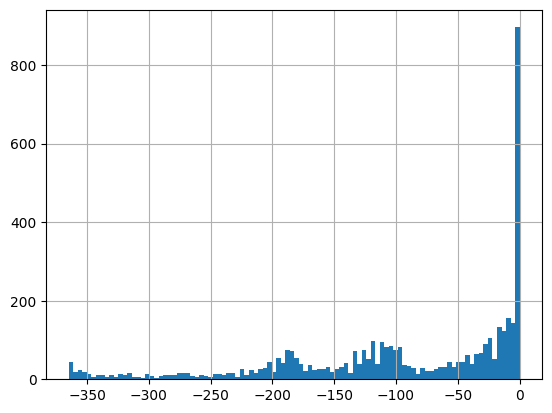

In [122]:
df_merged_filt['delta'].loc[indices].hist(bins=100)


In [82]:
df_merged_f_g['delta'].value_counts()

delta
0    4431
Name: count, dtype: int64

In [123]:
tokenizer = AutoTokenizer.from_pretrained("CLTL/MedRoBERTa.nl")
model = AutoModelForMaskedLM.from_pretrained("CLTL/MedRoBERTa.nl")

In [124]:
def splitter_512(t):
    sections = []
    how_many_512 = len(t)//512
    if how_many_512 > 1:
        for i in range(how_many_512):
            sections.append(t[i*512: (512*i) + 512])

        sections.append(t[(512*i) + 512:])
    else:
        sections.append(t)
    return sections

In [129]:
df_cooked = pd.DataFrame(columns=['ids'])
#df_cooked['chunked_text'] = df_merged_f_g.text.apply(splitter_512)
#df_cooked

In [134]:
def to_ids(chunk):
    return tokenizer(chunk,return_attention_mask=False,return_tensors='pt',padding=True)['input_ids']

In [135]:
df_cooked['ids'] = df_merged_f_g.text.apply(to_ids)


In [136]:
df_cooked['ids'].iloc[0]

tensor([[    0, 14503, 22082,  ..., 14388,   203,     2]])